In [1]:
import os
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import json
import duckdb


In [2]:
os.chdir("..")
from src.encode_cat_vars import compute_and_save_mappings, load_mappings, encode_dataframe
mappings = compute_and_save_mappings()

Computing category mappings using SQL...
Mappings saved to data/


In [3]:
STATS_PATH = "data/mileage_stats.json"
with open(STATS_PATH, 'r') as f:
    stats = json.load(f)
    
global_mean_mileage = float(stats['mean_mileage'])
global_std_mileage = float(stats['std_mileage'])

# Calculate priors
# We use the log of the global mean as the center for the prior
prior_mu = np.log(global_mean_mileage)
# We use the log of the global SD as the center for the shape parameter (sigma)
prior_sigma = np.log(global_std_mileage) 

In [4]:
con = duckdb.connect("uk_car_analyser.duckdb")
df = con.execute( """
WITH valid_makes AS (
    -- 1. Identify makes with sufficient data
    SELECT make
    FROM 'data/mot_last_test.parquet'
    GROUP BY make
    HAVING COUNT(DISTINCT registration) > 10000
)
-- 2. Select only rows belonging to those valid makes
SELECT
    make, model, fuelType, engineSize_bucket,
    defect_count_advisory, defect_count_dangerous,
    mileage_estimate, event_interval
FROM 'data/mot_last_test.parquet'
WHERE make IN (SELECT make FROM valid_makes)
LIMIT 50000
""").df()



In [8]:
# 3. Preprocessing data
# --- code categorical variables for pymc ---
df = encode_dataframe(df, mappings)

# --- Continuous (Using Fixed Stats) ---
#df['mileage_std'] = (df['mileage_estimate'] - mean_mileage) / std_mileage
df['log_mileage'] = np.log(df['mileage_estimate'])


In [10]:
make_ids = df['make_id'].values
model_ids = df['model_id'].values
engineSize_bucket_ids = df['engineSize_bucket_id'].values
fuelType_ids = df['fuelType_id'].values
defect_advisory = df['defect_count_advisory'].values
defect_dangerous = df['defect_count_dangerous'].values
#log_time = df['log_time'].values
log_mileage = df['log_mileage'].values
event_interval = df['event_interval'].values

In [11]:
y = np.log(df['mileage_estimate'].values)
event = np.asarray(event_interval)

with pm.Model(coords={
    "make_id": np.arange(df['make'].nunique()),
    "model_id": np.arange(df['model'].nunique()),
    "engineSize_bucket_id": np.arange(df['engineSize_bucket'].nunique()),
    "fuelType_id": np.arange(df['fuelType'].nunique())
}) as hierarchical_weibull:

    # Global intercept & scale parameter
    mu_global = pm.Normal('mu_global', mu=float(prior_mu), sigma=0.5)
    sigma_global = pm.HalfNormal('sigma_global', sigma=prior_sigma)

    # Hierarchical scale hyperpriors to pool group variations
    sigma_make = pm.HalfStudentT('sigma_make', nu=3, sigma=2.5)
    sigma_model = pm.HalfStudentT('sigma_model', nu=3, sigma=2.5)
    sigma_engine = pm.HalfStudentT('sigma_engine', nu=3, sigma=2.5)
    sigma_fuel = pm.HalfStudentT('sigma_fuel', nu=3, sigma=2.5)

    # Effects (Non-centered parameterization for stable sampling)
    make_raw = pm.Normal('make_raw', mu=0, sigma=1, dims='make_id')
    model_raw = pm.Normal('model_raw', mu=0, sigma=1, dims='model_id')
    engine_raw = pm.Normal('engine_raw', mu=0, sigma=1, dims='engineSize_bucket_id')
    fuel_raw = pm.Normal('fuel_raw', mu=0, sigma=1, dims='fuelType_id')

    make_effect = pm.Deterministic('make_effect', make_raw * sigma_make, dims='make_id')
    model_effect = pm.Deterministic('model_effect', model_raw * sigma_model, dims='model_id')
    engine_effect = pm.Deterministic('engine_effect', engine_raw * sigma_engine, dims='engineSize_bucket_id')
    fuel_effect = pm.Deterministic('fuel_effect', fuel_raw * sigma_fuel, dims='fuelType_id')
    
    beta_advisory = pm.Normal('beta_advisory', mu=0, sigma=1)
    beta_dangerous = pm.Normal('beta_dangerous', mu=0, sigma=1)

    # Linear Predictor
    mu = (
        mu_global 
        + make_effect[make_ids] 
        + model_effect[model_ids] 
        + engine_effect[engineSize_bucket_ids] 
        + fuel_effect[fuelType_ids]
        + beta_advisory * defect_advisory   
        + beta_dangerous * defect_dangerous     
    )

    # Standardized residual: z = (log(T) - mu) / sigma
    z = (y - mu) / sigma_global

    # Correct Log-Weibull Likelihood:
    # Event (uncensored): log(f(y)) = -log(sigma) + z - exp(z)
    # Censored:           log(S(y)) = -exp(z)
    log_lik_obs = -pm.math.log(sigma_global) + z - pm.math.exp(z)
    log_lik_cens = -pm.math.exp(z)

    log_lik = pm.math.switch(pm.math.eq(event, 1), log_lik_obs, log_lik_cens)

    # Sum across all observations
    trace = pm.sample(10000, tune=5000, target_accept=0.9, random_seed=42, return_inferencedata=True, nuts_sampler="nutpie")
    #approx = pm.fit(n=40000, method="advi", obj_optimizer=pm.adam(learning_rate=0.01))



C:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,15000,0,0.18,31
,15000,0,0.16,31
,15000,0,0.16,31
,15000,0,0.16,31


In [12]:
# Check divergences
div_count = sum(trace.posterior.attrs.get('diverging', [0]))
print(f"Divergent transitions: {div_count} / {trace.posterior.dims['draw'] * trace.posterior.dims['chain']}")

# If > 10% divergent, the model is still problematic — consider dropping model level
if div_count / (2000 * 4) > 0.1:
    print("WARNING: >10% divergences. Consider dropping the model-level hierarchy.")

# Check R-hat
rhat = az.rhat(trace.posterior, var_names=['mu_global', 'sigma_global', 'sigma_make', 'sigma_model', 'beta_advisory', 'beta_dangerous'])
print(rhat)

# Check ESS
ess = az.ess(trace.posterior, var_names=['mu_global', 'sigma_global', 'sigma_make', 'sigma_model'])
print(ess)

# Check effective sample size per parameter — low ESS on sigma_hyperpriors means poor mixing
print("\nEffective Sample Size:")
print(ess)

C:\Users\Grum\AppData\Local\Temp\ipykernel_19768\3429849483.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Divergent transitions: {div_count} / {trace.posterior.dims['draw'] * trace.posterior.dims['chain']}")


Divergent transitions: 0 / 40000
<xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       float64 8B 1.0
    sigma_global    float64 8B 1.0
    sigma_make      float64 8B 1.0
    sigma_model     float64 8B 1.0
    beta_advisory   float64 8B 1.0
    beta_dangerous  float64 8B 0.9999
Attributes:
    created_at:                 2026-09-03T21:13:13.433536+00:00
    arviz_version:              0.23.4
    inference_library:          nutpie
    inference_library_version:  0.16.8
    sampling_time:              34.04886507987976
    tuning_steps:               5000
<xarray.Dataset> Size: 32B
Dimensions:       ()
Data variables:
    mu_global     float64 8B 1.12e+05
    sigma_global  float64 8B 3.752e+04
    sigma_make    float64 8B 5.794e+04
    sigma_model   float64 8B 6.06e+04
Attributes:
    created_at:                 2026-09-03T21:13:13.433536+00:00
    arviz_version:              0.23.4
    inference_library:          nutpie
    inference_library_version:  0.

In [14]:
vars_to_check = [
    'mu_global', 'sigma_global', 
    'make_effect', 'model_effect', 'engine_effect', 'fuel_effect',
    'beta_advisory', 'beta_dangerous'
]
print("Available variables in trace:", list(trace.posterior.data_vars))



rhat = az.rhat(trace.posterior, var_names=vars_to_check)
print(rhat)


Available variables in trace: ['mu_global', 'sigma_global_log__', 'sigma_make_log__', 'sigma_model_log__', 'sigma_engine_log__', 'sigma_fuel_log__', 'make_raw', 'model_raw', 'engine_raw', 'fuel_raw', 'beta_advisory', 'beta_dangerous', 'sigma_global', 'sigma_make', 'sigma_model', 'sigma_engine', 'sigma_fuel', 'make_effect', 'model_effect', 'engine_effect', 'fuel_effect']
<xarray.Dataset> Size: 49kB
Dimensions:               (make_id: 70, model_id: 2963,
                           engineSize_bucket_id: 14, fuelType_id: 5)
Coordinates:
  * make_id               (make_id) int64 560B 0 1 2 3 4 5 ... 64 65 66 67 68 69
  * model_id              (model_id) int64 24kB 0 1 2 3 ... 2959 2960 2961 2962
  * engineSize_bucket_id  (engineSize_bucket_id) int64 112B 0 1 2 3 ... 11 12 13
  * fuelType_id           (fuelType_id) int64 40B 0 1 2 3 4
Data variables:
    mu_global             float64 8B 1.0
    sigma_global          float64 8B 1.0
    make_effect           (make_id) float64 560B 1.0 1.0 1.0 

In [15]:
# Calculate the mean and SD of the posterior
posterior_stats = trace.posterior.mean(dim=['chain', 'draw'])
print("Posterior Means:")
print(posterior_stats[['mu_global', 'sigma_global', 'beta_advisory', 'beta_dangerous']])

# Check the SD for the hierarchical effects
print("\nMake Effect Mean (should vary):")
print(posterior_stats['make_effect'])

Posterior Means:
<xarray.Dataset> Size: 32B
Dimensions:         ()
Data variables:
    mu_global       float64 8B 11.62
    sigma_global    float64 8B 8.675
    beta_advisory   float64 8B -0.006756
    beta_dangerous  float64 8B 0.0005322
Attributes:
    created_at:                 2026-09-03T21:13:13.433536+00:00
    arviz_version:              0.23.4
    inference_library:          nutpie
    inference_library_version:  0.16.8
    sampling_time:              34.04886507987976
    tuning_steps:               5000

Make Effect Mean (should vary):
<xarray.DataArray 'make_effect' (make_id: 70)> Size: 560B
array([ 0.01026519, -0.00164301,  0.03597984,  0.02553596,  0.02809722,
        0.02432247,  0.00434304,  0.0251646 , -0.02522535,  0.00119298,
        0.01281115, -0.0199442 ,  0.05848228,  0.00013796, -0.00099153,
        0.01553096, -0.0057287 ,  0.00681601, -0.00344036, -0.01875709,
       -0.00319311, -0.01474401,  0.00668113,  0.00492398, -0.01602051,
       -0.00878925, -0.000578

C:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\arviz\plots\traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (21), generating only 20 plots
  warnings.warn(


array([[<Axes: title={'center': 'mu_global'}>,
        <Axes: title={'center': 'mu_global'}>],
       [<Axes: title={'center': 'sigma_global_log__'}>,
        <Axes: title={'center': 'sigma_global_log__'}>],
       [<Axes: title={'center': 'sigma_make_log__'}>,
        <Axes: title={'center': 'sigma_make_log__'}>],
       [<Axes: title={'center': 'sigma_model_log__'}>,
        <Axes: title={'center': 'sigma_model_log__'}>],
       [<Axes: title={'center': 'sigma_engine_log__'}>,
        <Axes: title={'center': 'sigma_engine_log__'}>],
       [<Axes: title={'center': 'sigma_fuel_log__'}>,
        <Axes: title={'center': 'sigma_fuel_log__'}>],
       [<Axes: title={'center': 'make_raw'}>,
        <Axes: title={'center': 'make_raw'}>],
       [<Axes: title={'center': 'model_raw'}>,
        <Axes: title={'center': 'model_raw'}>],
       [<Axes: title={'center': 'engine_raw'}>,
        <Axes: title={'center': 'engine_raw'}>],
       [<Axes: title={'center': 'fuel_raw'}>,
        <Axes: titl

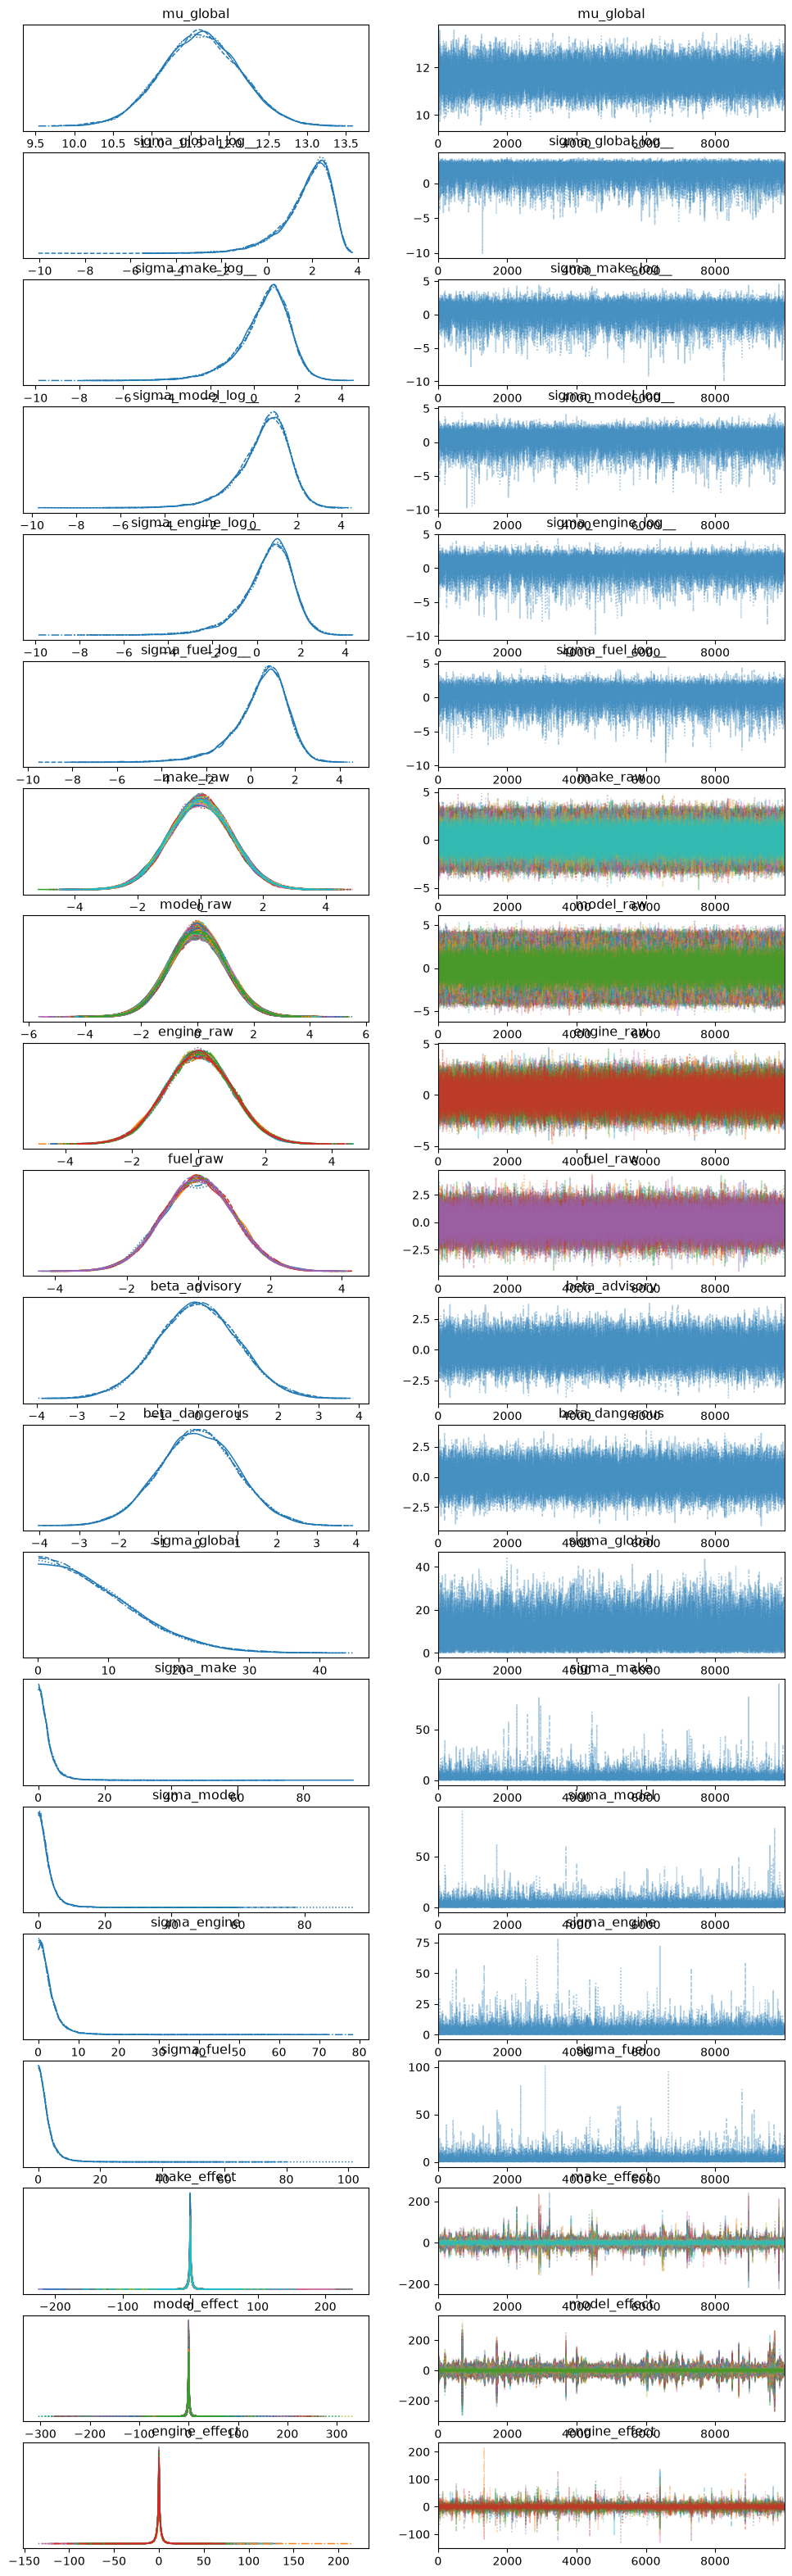

In [16]:
az.plot_trace(trace)

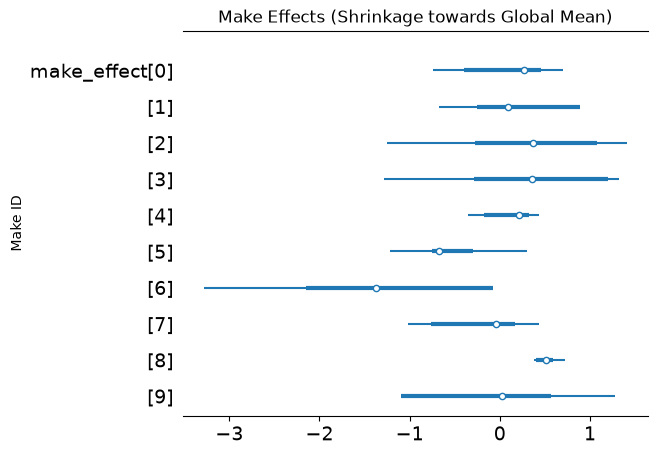

In [11]:
# 1. Plot the Make Effects (Forest Plot)
# This shows how much each Make deviates from the Global Mean
az.plot_forest(trace, var_names=['make_effect'], kind='forestplot', combined=True,
               coords={'make_id': range(10)}) # Show first 10 makes for clarity
plt.title('Make Effects (Shrinkage towards Global Mean)')
plt.ylabel('Make ID')
plt.show()


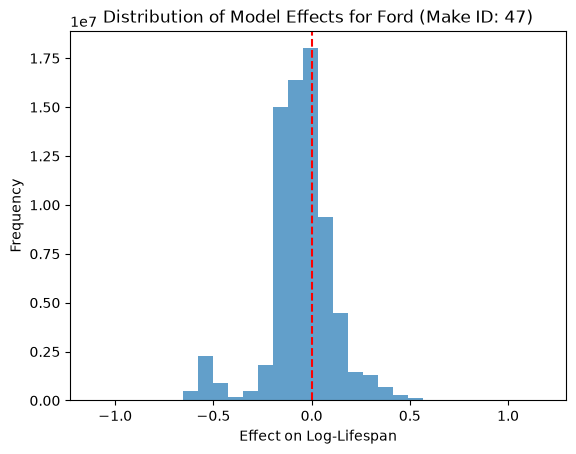

In [12]:

# 2. Plot the Model Effects for a specific Make (e.g., Ford)
# You need to find the Make ID for Ford first
ford_make_id = df[df['make'] == 'FORD']['make_id'].iloc[0]

# Filter the posterior for Ford's models
ford_model_effects = trace.posterior['model_effect'].sel(model_id=df[df['make']=='FORD']['model_id'].values)

# Plot histogram of Ford's models
ford_model_effects.plot.hist(bins=30, alpha=0.7)
plt.title(f'Distribution of Model Effects for Ford (Make ID: {ford_make_id})')
plt.xlabel('Effect on Log-Lifespan')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--') # Show global mean
plt.show()

In [43]:
print(df['make'].unique())

['SKODA' 'VOLKSWAGEN' 'MITSUBISHI' 'MAZDA' 'VAUXHALL' 'TOYOTA' 'FORD'
 'MERCEDES-BENZ' 'NISSAN' 'HONDA' 'LAND ROVER' 'PEUGEOT' 'HARLEY DAVIDSON'
 'BENTLEY' 'BMW' 'LAMBORGHINI' 'PORSCHE' 'KIA' 'MINI' 'FERRARI' 'AUDI'
 'ABARTH' 'LEXUS' 'SMART (MCC)' 'ALFA ROMEO' 'VOLVO' 'ASTON MARTIN'
 'MERCEDES' 'RENAULT' 'JEEP' 'ROLLS ROYCE' 'MCLAREN' 'CITROEN' 'JAGUAR'
 'SEAT' 'TESLA' 'CADILLAC' 'LAMBO' 'FIAT' 'HYUNDAI' 'SUZUKI' 'DACIA'
 'WESTFIELD ELEVEN' 'ROVER' 'SUBARU' 'SAAB' 'MAN' 'DAIMLER' 'ISUZU'
 'IVECO' 'CHEVROLET' 'OPEL' 'MG' 'CARVER CARGO' 'MASERATI' 'SSANGYONG'
 'SMART' 'LOTUS' 'CHRYSLER' 'BUELL' 'DODGE' 'LDV' 'AUTO-SLEEPERS'
 'DAIHATSU' 'CHRYSLER-JEEP' 'HARLEY-DAVIDSON' 'YAMAHA' 'PROTON' 'KAWASAKI'
 'MOTO GUZZI' 'PERODUA' 'TRIUMPH' 'DS' 'PONTIAC' 'GENERAL MOTORS'
 'INFINITI' 'KTM' 'REWACO' 'APRILIA' 'DUCATI' 'CUPRA' 'TALBOT' 'CAN-AM'
 'VOLKSWAGEN GOLF TREND FSI 1.6L' 'DAEWOO' 'DUCATO CARTHAGO 150' 'DFSK'
 'CHEVROLET GMC' 'MERCURY' 'SCION' 'GREAT WALL' 'PIAGGIO' 'RENAULT TRUCKS'
 'MORGAN' 

In [13]:
# Save the PyMC trace to a NetCDF file
trace.to_netcdf('data/bayes_weib_hier_surv_model_trace.nc')
print("Model trace saved to model_trace.nc")


Model trace saved to model_trace.nc


In [29]:
print(df['mileage_estimate'].mean())

99009.91700836785
